In [1]:
import numpy as np
from scipy import stats


In [8]:
def random_walking(N):
    a=1
    x=0
    for j in range(N):

        i=np.random.randint(0,2)
        if i==0:
            paso=-1
        else:
            paso=1
        x=x+a*paso
    return x
N=100
tau=2 #dos segundos
position=np.array([random_walking(N) for j in range(1000)])

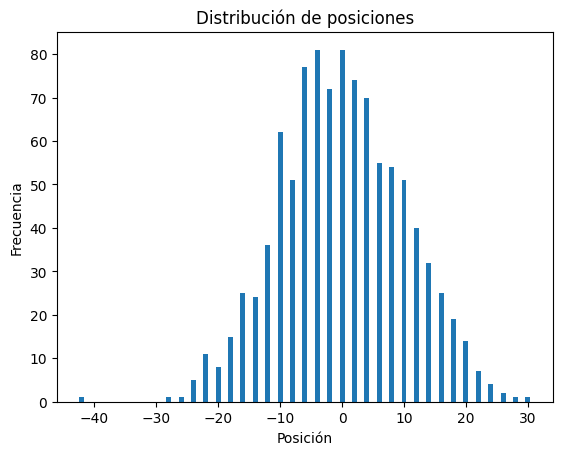

In [3]:
from collections import Counter
import matplotlib.pyplot as plt
conteo = Counter(position)
elementos = list(conteo.keys())
frecuencias = list(conteo.values())
plt.bar(elementos, frecuencias)
plt.xlabel('Posición')
plt.ylabel('Frecuencia')
plt.title('Distribución de posiciones')
plt.show()

In [4]:
from scipy.special import comb

def p(n,N):
    phi=0.5
    return phi**n*(1-phi)**(N-n)*(comb(N,n))
N=np.linspace(100,200,101)
E_x2=np.zeros(len(N))
for i in range(len(N)):
    position=np.array([random_walking(np.int64(N[i])) for j in range(1000)])
    conteo = Counter(position)
    elementos = list(conteo.keys())
    frecuencias = list(conteo.values())
    Normalization=np.sum(frecuencias)
    E_x=np.sum([n*(m/Normalization) for n,m in zip(elementos,frecuencias)])
    E_x2[i]=np.sum([n**2*(m/Normalization) for n,m in zip(elementos,frecuencias)])
m, b, r_value, p_value, std_err = stats.linregress(N, E_x2)

y=m*N+b


In [11]:
a_2=1/m
print("D= "+str(a_2/(2*tau)))

D= 0.24591038850140556


Text(0, 0.5, '$E[x^2]$')

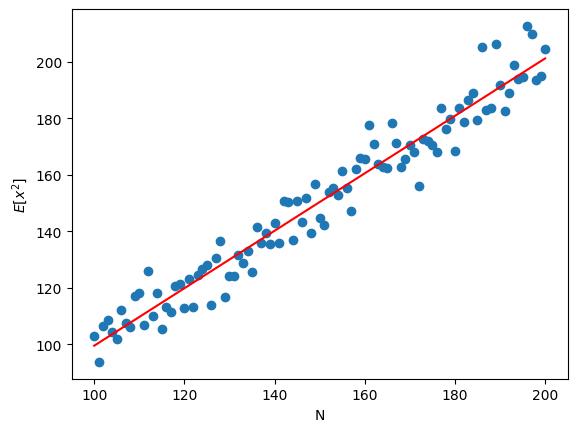

In [6]:
plt.scatter(N,E_x2)
plt.plot(N,y,"r")
plt.xlabel("N")
plt.ylabel(r'$E[x^2]$')